<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [5]:
df = pd.read_csv("dmengeli_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df['project'].unique()

array(['pseudomanifold_aleph', 'trichter_rf', 'evalf_nutils',
       'exascaleinfolab_bench-vldb20', 'ashiklom_edr-da',
       'oxfordska_oskar', 'ctlab_fgsea', 'lampspuc_statespacemodels.jl',
       'siepic_siepic_ebeam_pdk', 'paulhancock_aegean'], dtype=object)

In [6]:
projects = [
    'pseudomanifold_aleph',
    'trichter_rf',
    'evalf_nutils',
    'exascaleinfolab_bench-vldb20',
    'ashiklom_edr-da',
    'oxfordska_oskar',
    'ctlab_fgsea',
    'lampspuc_statespacemodels.jl',
    'siepic_siepic_ebeam_pdk',
    'paulhancock_aegean'
]

monthly_data = {}

for prj in projects:
    df1 = df[df['project'] == prj]

    df2 = df1.groupby('Month').size().reset_index(name='Commits')

    monthly_counts = df2.copy()
    monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])

    full_date_range = pd.DataFrame({
        'time': pd.date_range(
            start=monthly_counts['time'].min(),
            end=monthly_counts['time'].max(),
            freq='MS'
        )
    })

    monthly_counts = pd.merge(
        full_date_range,
        monthly_counts,
        on='time',
        how='left'
    ).fillna(0)

    monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')

    # Store this project's monthly data
    monthly_data[prj] = monthly_counts

    print(prj)
    print(monthly_counts)


pseudomanifold_aleph
          time    Month  Commits
0   2016-09-01  2016-09     88.0
1   2016-10-01  2016-10      8.0
2   2016-11-01  2016-11     76.0
3   2016-12-01  2016-12     85.0
4   2017-01-01  2017-01     78.0
..         ...      ...      ...
102 2025-03-01  2025-03      0.0
103 2025-04-01  2025-04      0.0
104 2025-05-01  2025-05      0.0
105 2025-06-01  2025-06      0.0
106 2025-07-01  2025-07      1.0

[107 rows x 3 columns]
trichter_rf
          time    Month  Commits
0   2013-02-01  2013-02      3.0
1   2013-03-01  2013-03      0.0
2   2013-04-01  2013-04      0.0
3   2013-05-01  2013-05      0.0
4   2013-06-01  2013-06      0.0
..         ...      ...      ...
152 2025-10-01  2025-10      0.0
153 2025-11-01  2025-11      0.0
154 2025-12-01  2025-12      1.0
155 2026-01-01  2026-01      0.0
156 2026-02-01  2026-02      4.0

[157 rows x 3 columns]
evalf_nutils
          time    Month  Commits
0   2012-02-01  2012-02      2.0
1   2012-03-01  2012-03      9.0
2   2012-04-01 

/tmp/ipykernel_715/960545013.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
/tmp/ipykernel_715/960545013.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
/tmp/ipykernel_715/960545013.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])


In [10]:
for prj, monthly_counts in monthly_data.items():

    # Keep only the two required columns
    timeseries = monthly_counts[['Month', 'Commits']].copy()

    # Match the required column name
    timeseries = timeseries.rename(columns={'Commits': '#Commits'})

    # Make commit counts integers instead of values like 5.0
    timeseries['#Commits'] = timeseries['#Commits'].astype(int)

    # Save the CSV
    filename = "dmengeli_commits_timeseries_" + prj + ".csv"

    timeseries.to_csv(
        filename,
        sep=";",
        index=False
    )

    print("Created:", filename)

Created: dmengeli_commits_timeseries_pseudomanifold_aleph.csv
Created: dmengeli_commits_timeseries_trichter_rf.csv
Created: dmengeli_commits_timeseries_evalf_nutils.csv
Created: dmengeli_commits_timeseries_exascaleinfolab_bench-vldb20.csv
Created: dmengeli_commits_timeseries_ashiklom_edr-da.csv
Created: dmengeli_commits_timeseries_oxfordska_oskar.csv
Created: dmengeli_commits_timeseries_ctlab_fgsea.csv
Created: dmengeli_commits_timeseries_lampspuc_statespacemodels.jl.csv
Created: dmengeli_commits_timeseries_siepic_siepic_ebeam_pdk.csv
Created: dmengeli_commits_timeseries_paulhancock_aegean.csv


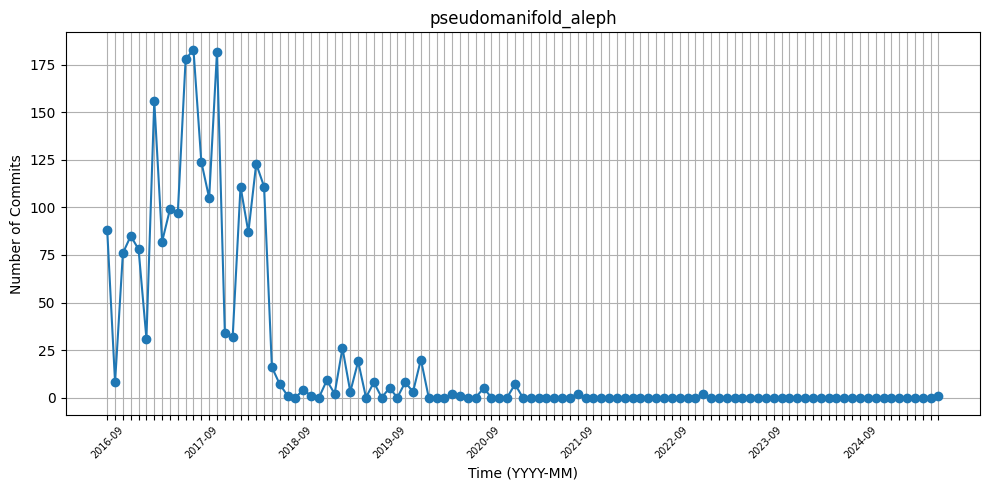

Created: dmengeli_timeseries_pseudomanifold_aleph.png


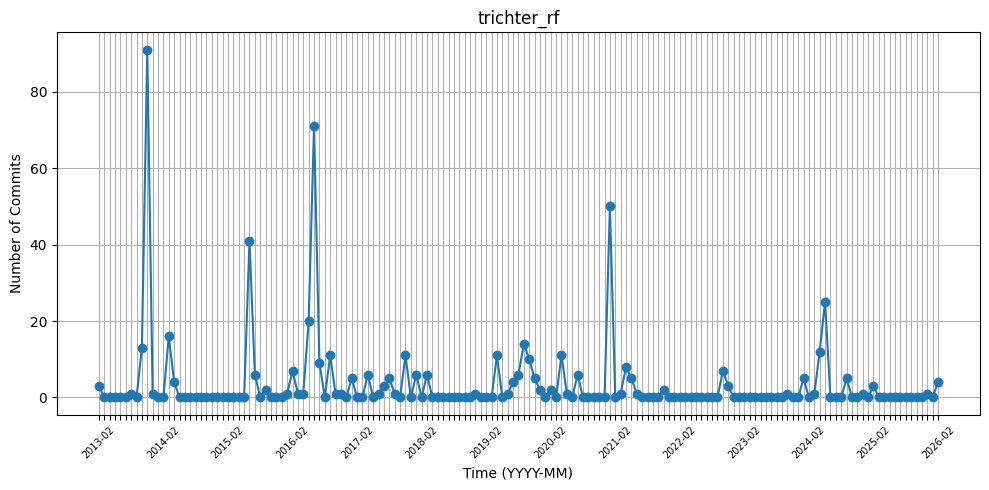

Created: dmengeli_timeseries_trichter_rf.png


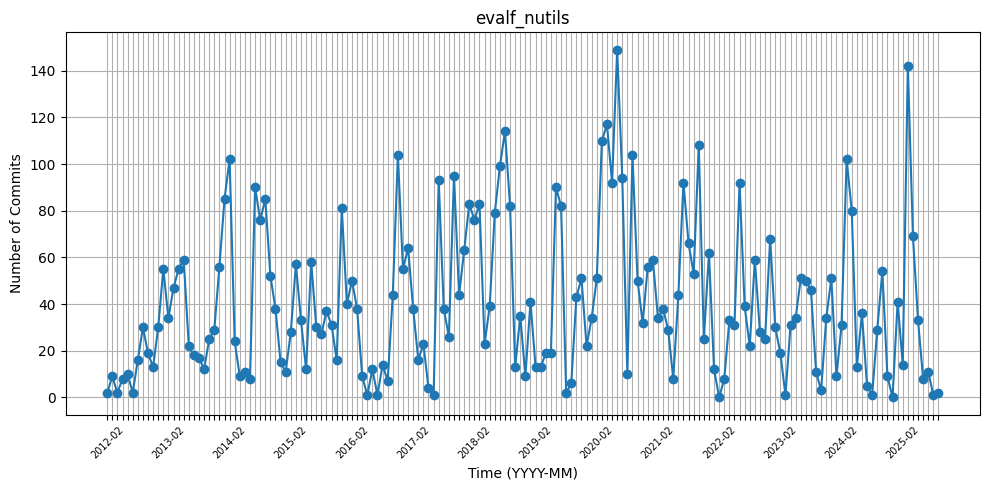

Created: dmengeli_timeseries_evalf_nutils.png


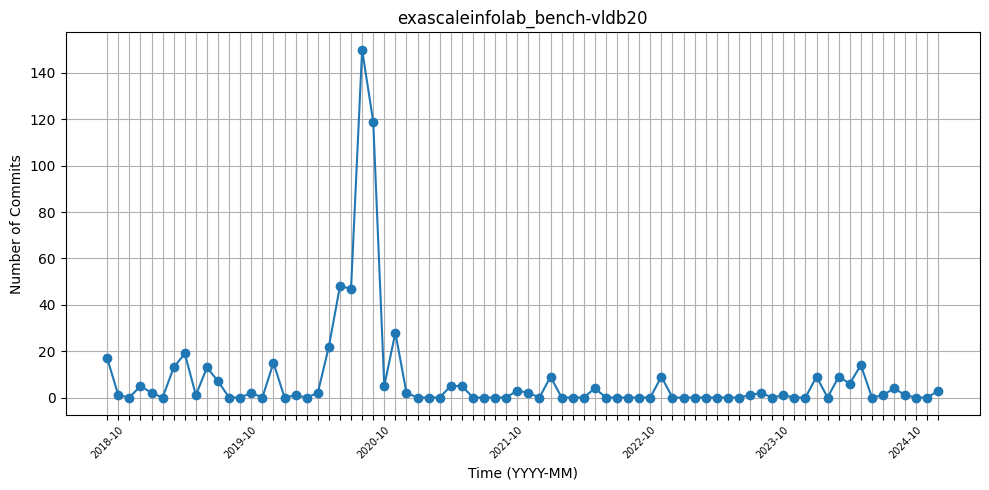

Created: dmengeli_timeseries_exascaleinfolab_bench-vldb20.png


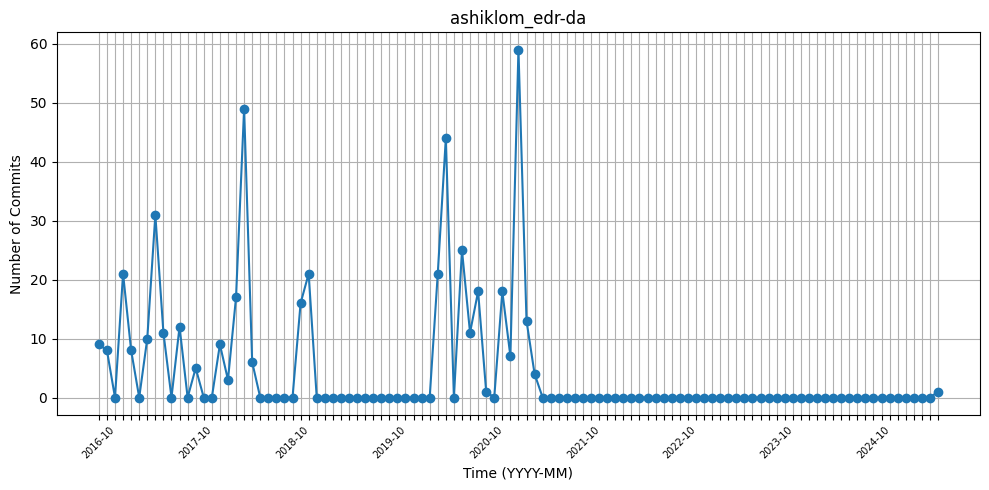

Created: dmengeli_timeseries_ashiklom_edr-da.png


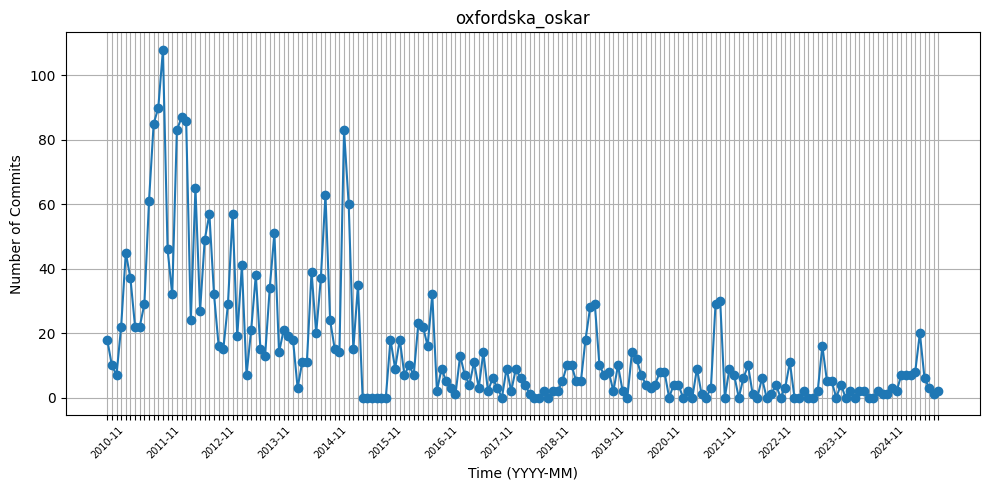

Created: dmengeli_timeseries_oxfordska_oskar.png


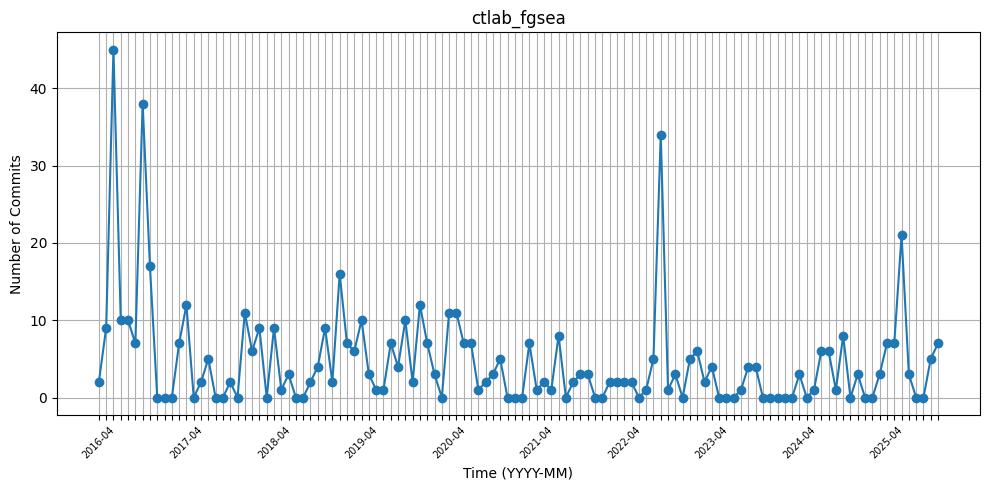

Created: dmengeli_timeseries_ctlab_fgsea.png


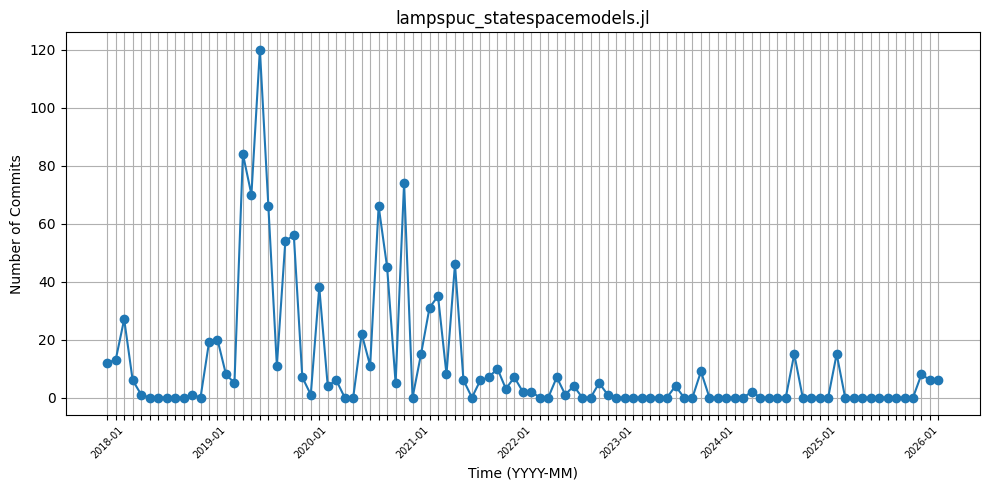

Created: dmengeli_timeseries_lampspuc_statespacemodels.jl.png


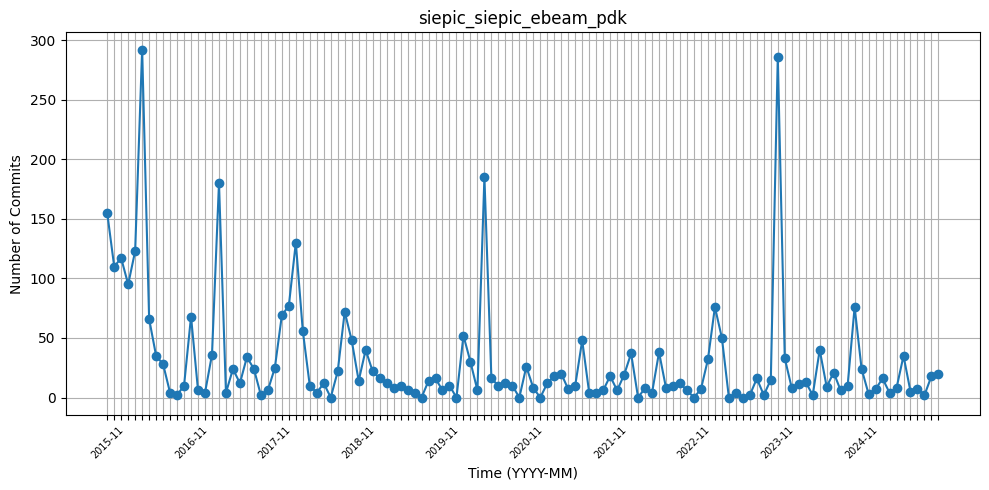

Created: dmengeli_timeseries_siepic_siepic_ebeam_pdk.png


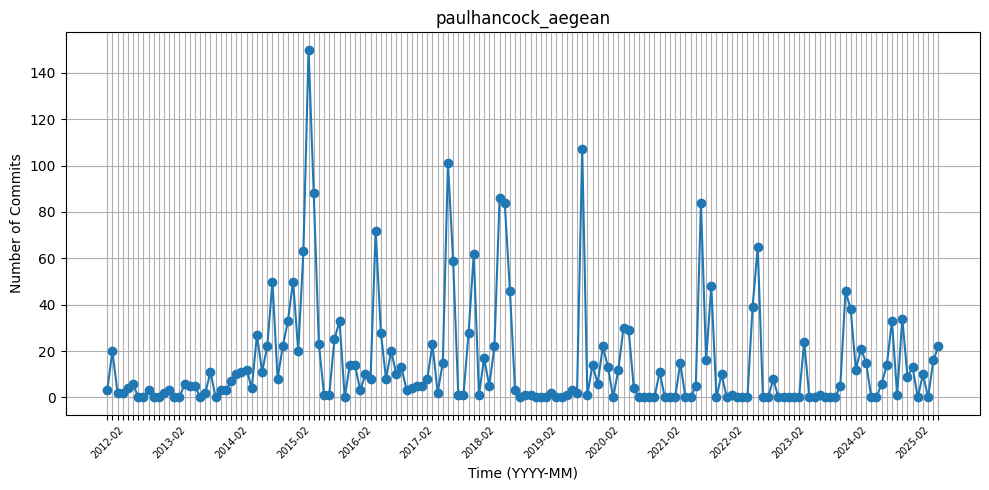

Created: dmengeli_timeseries_paulhancock_aegean.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

projects = df['project'].unique()

for prj in projects:

    # Read this project's time-series CSV
    filename = "dmengeli_commits_timeseries_" + prj + ".csv"
    timeseries = pd.read_csv(filename, sep=";")

    # Create plot
    plt.figure(figsize=(10, 5))

    plt.plot(
        timeseries["Month"],
        timeseries["#Commits"],
        marker="o",
        linestyle="-"
    )

    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(prj)
    plt.grid(True)

    # Only display roughly one X-axis label per year
    ax = plt.gca()
    for i, label in enumerate(ax.xaxis.get_ticklabels()):
        if i % 12 != 0:
            label.set_visible(False)

    plt.xticks(rotation=45, fontsize=7)
    plt.tight_layout()

    # Save at 600 DPI
    output_filename = "dmengeli_timeseries_" + prj + ".png"
    plt.savefig(output_filename, dpi=600)

    plt.show()
    plt.close()

    print("Created:", output_filename)

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

In [12]:
gap_stats = []

for prj in projects:
    # Load this project's monthly time series
    filename = "dmengeli_commits_timeseries_" + prj + ".csv"
    ts = pd.read_csv(filename, sep=";")

    # Make sure months are chronological
    ts["MonthDate"] = pd.to_datetime(ts["Month"], format="%Y-%m")
    ts = ts.sort_values("MonthDate").reset_index(drop=True)

    gaps = []
    gap_start = None
    gap_length = 0

    for i in range(len(ts)):
        if ts.loc[i, "#Commits"] == 0:

            # Beginning of a new gap
            if gap_start is None:
                gap_start = i

            gap_length += 1

        else:
            # We just reached the end of a gap
            if gap_start is not None:
                gaps.append({
                    "start_index": gap_start,
                    "end_index": i - 1,
                    "length": gap_length
                })

                gap_start = None
                gap_length = 0

    # Handle a gap that continues through the final month
    if gap_start is not None:
        gaps.append({
            "start_index": gap_start,
            "end_index": len(ts) - 1,
            "length": gap_length
        })

    # Find longest gap
    if len(gaps) > 0:
        longest_gap = max(gaps, key=lambda x: x["length"])

        longest_start = ts.loc[
            longest_gap["start_index"], "Month"
        ]

        longest_end = ts.loc[
            longest_gap["end_index"], "Month"
        ]

        longest_length = longest_gap["length"]

        # Commits occurring after the longest gap
        commits_after_gap = ts.loc[
            longest_gap["end_index"] + 1:, "#Commits"
        ].sum()

    else:
        longest_start = None
        longest_end = None
        longest_length = 0
        commits_after_gap = 0

    # Count gaps lasting at least 3 months
    number_of_gaps = sum(
        1 for gap in gaps if gap["length"] >= 3
    )

    gap_stats.append({
        "project": prj,
        "LongestGapStart": longest_start,
        "LongestGapEnd": longest_end,
        "LongestGapLength": longest_length,
        "NumCommitsAfterLastGap": int(commits_after_gap),
        "NumberOfGapsInTimeline": number_of_gaps
    })

gap_df = pd.DataFrame(gap_stats)

gap_df

,project,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,pseudomanifold_aleph,2023-02,2025-06,29,1,5
1,trichter_rf,2014-05,2015-05,13,425,11
2,evalf_nutils,2022-02,2022-02,1,1456,0
3,exascaleinfolab_bench-vldb20,2023-01,2023-07,7,51,5
4,ashiklom_edr-da,2021-05,2025-05,49,1,3
5,oxfordska_oskar,2015-06,2015-11,6,741,1
6,ctlab_fgsea,2023-11,2024-03,5,81,4
7,lampspuc_statespacemodels.jl,2025-04,2025-12,9,20,6
8,siepic_siepic_ebeam_pdk,2018-07,2018-07,1,1838,0
9,paulhancock_aegean,2022-12,2023-04,5,320,6


In [13]:
github_stats = pd.DataFrame([
    ['pseudomanifold_aleph', 108, 15, '2025-07-16'],
    ['trichter_rf', 124, 65, '2026-05-05'],
    ['evalf_nutils', 102, 47, '2026-09-21'],
    ['exascaleinfolab_bench-vldb20', 41, 15, '2025-01-23'],
    ['ashiklom_edr-da', 7, 4, '2025-06-20'],
    ['oxfordska_oskar', 82, 46, '2026-07-23'],
    ['ctlab_fgsea', 459, 77, '2026-09-22'],
    ['lampspuc_statespacemodels.jl', 291, 30, '2026-08-24'],
    ['siepic_siepic_ebeam_pdk', 286, 184, '2026-02-13'],
    ['paulhancock_aegean', 52, 14, '2025-07-28']
], columns=[
    'project',
    'number of stars',
    'number of forks',
    'last commit date'
])

github_stats

,project,number of stars,number of forks,last commit date
0,pseudomanifold_aleph,108,15,2025-07-16
1,trichter_rf,124,65,2026-05-05
2,evalf_nutils,102,47,2026-09-21
3,exascaleinfolab_bench-vldb20,41,15,2025-01-23
4,ashiklom_edr-da,7,4,2025-06-20
5,oxfordska_oskar,82,46,2026-07-23
6,ctlab_fgsea,459,77,2026-09-22
7,lampspuc_statespacemodels.jl,291,30,2026-08-24
8,siepic_siepic_ebeam_pdk,286,184,2026-02-13
9,paulhancock_aegean,52,14,2025-07-28


In [15]:
# Turn project from the index into a normal column
stats = df.groupby('project').agg(
    **{
        'number of commits': ('commit', 'nunique'),
        'number of authors': ('author', 'nunique'),
        'max time': ('time', 'max'),
        'min time': ('time', 'min')
    }
).reset_index()

stats

# Rename columns to match the assignment
stats = stats.rename(columns={
    'commits': 'number of commits',
    'authors': 'number of authors',
    'max_time': 'max time',
    'min_time': 'min time'
})

# Add GitHub statistics
stats = stats.merge(
    github_stats,
    on='project',
    how='left'
)

# Add inactivity-gap statistics
stats = stats.merge(
    gap_df,
    on='project',
    how='left'
)

stats

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,ashiklom_edr-da,458,5,1750426419,1477337165,7,4,2025-06-20,2021-05,2025-05,49,1,3
1,ctlab_fgsea,544,33,1762551642,1461616806,459,77,2026-09-22,2023-11,2024-03,5,81,4
2,evalf_nutils,6587,49,1757000677,1329989907,102,47,2026-09-21,2022-02,2022-02,1,1456,0
3,exascaleinfolab_bench-vldb20,607,10,1737636470,1539276296,41,15,2025-01-23,2023-01,2023-07,7,51,5
4,lampspuc_statespacemodels.jl,1113,35,1773935433,1516020652,291,30,2026-08-24,2025-04,2025-12,9,20,6
5,oxfordska_oskar,2743,24,1761294322,1289905814,82,46,2026-07-23,2015-06,2015-11,6,741,1
6,paulhancock_aegean,2402,23,1753841963,1330396617,52,14,2025-07-28,2022-12,2023-04,5,320,6
7,pseudomanifold_aleph,2222,10,1752677613,1473339037,108,15,2025-07-16,2023-02,2025-06,29,1,5
8,siepic_siepic_ebeam_pdk,3658,84,1761227477,1447480391,286,184,2026-02-13,2018-07,2018-07,1,1838,0
9,trichter_rf,554,11,1771950976,1361208896,124,65,2026-05-05,2014-05,2015-05,13,425,11


In [16]:
activity_patterns = {
    'ashiklom_edr-da': 'declining',
    'ctlab_fgsea': 'irregular',
    'evalf_nutils': 'irregular',
    'exascaleinfolab_bench-vldb20': 'declining',
    'lampspuc_statespacemodels.jl': 'declining',
    'oxfordska_oskar': 'declining',
    'paulhancock_aegean': 'irregular',
    'pseudomanifold_aleph': 'declining',
    'siepic_siepic_ebeam_pdk': 'irregular',
    'trichter_rf': 'irregular'
}

stats['ActivityPattern'] = stats['project'].map(activity_patterns)

stats

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,ashiklom_edr-da,458,5,1750426419,1477337165,7,4,2025-06-20,2021-05,2025-05,49,1,3,declining
1,ctlab_fgsea,544,33,1762551642,1461616806,459,77,2026-09-22,2023-11,2024-03,5,81,4,irregular
2,evalf_nutils,6587,49,1757000677,1329989907,102,47,2026-09-21,2022-02,2022-02,1,1456,0,irregular
3,exascaleinfolab_bench-vldb20,607,10,1737636470,1539276296,41,15,2025-01-23,2023-01,2023-07,7,51,5,declining
4,lampspuc_statespacemodels.jl,1113,35,1773935433,1516020652,291,30,2026-08-24,2025-04,2025-12,9,20,6,declining
5,oxfordska_oskar,2743,24,1761294322,1289905814,82,46,2026-07-23,2015-06,2015-11,6,741,1,declining
6,paulhancock_aegean,2402,23,1753841963,1330396617,52,14,2025-07-28,2022-12,2023-04,5,320,6,irregular
7,pseudomanifold_aleph,2222,10,1752677613,1473339037,108,15,2025-07-16,2023-02,2025-06,29,1,5,declining
8,siepic_siepic_ebeam_pdk,3658,84,1761227477,1447480391,286,184,2026-02-13,2018-07,2018-07,1,1838,0,irregular
9,trichter_rf,554,11,1771950976,1361208896,124,65,2026-05-05,2014-05,2015-05,13,425,11,irregular


In [17]:
stats.to_csv(
    "dmengeli_project_stats.csv",
    sep=";",
    index=False
)

## Interpretation

The ten projects show a mixture of declining and irregular activity patterns. I classified a project as declining when its overall activity generally decreased over time, even if there were occasional later spikes. I classified a project as irregular when its activity fluctuated substantially without a clear long-term direction or predictable cyclical pattern. None of the projects showed a sufficiently clear repeated seasonal pattern to be classified as cyclical.

- ashiklom_edr-da — Declining: Activity was considerably higher during the earlier portion of the timeline before decreasing. The project eventually experienced an extended period with almost no activity. It had 3 gaps of at least three months, and its longest inactivity gap lasted 49 months, from 2021-05 through 2025-05.

- ctlab_fgsea — Irregular: Commit activity varies considerably across the timeline, with periods of relatively low activity interrupted by several substantial spikes. There is not a clear sustained upward or downward trajectory. It had 4 gaps of at least three months, with its longest gap lasting 5 months, from 2023-11 through 2024-03.

- evalf_nutils — Irregular: This project remained active throughout nearly its entire timeline, but the amount of activity varied substantially from month to month. It had 0 gaps of at least three months. Its longest period with zero commits was only 1 month, in 2022-02.

- exascaleinfolab_bench-vldb20 — Declining: Activity reached its highest levels around the earlier/middle portion of the project's timeline and was generally lower afterward. Later activity continued but at substantially reduced levels. It had 5 gaps of at least three months, and its longest gap lasted 7 months, from 2023-01 through 2023-07.

- lampspuc_statespacemodels.jl — Declining: The project experienced its highest activity earlier in its history, followed by generally lower and more intermittent activity in later years. It had 6 gaps of at least three months, with its longest gap lasting 9 months, from 2025-04 through 2025-12.

- oxfordska_oskar — Declining: The project had relatively high activity during its earlier years, followed by generally lower activity later in the timeline, although occasional spikes continued to occur. It had 1 gap of at least three months, lasting 6 months from 2015-06 through 2015-11.

- paulhancock_aegean — Irregular: The timeline contains repeated fluctuations between lower activity and large isolated spikes without an obvious predictable cycle or consistent long-term direction. It had 6 gaps of at least three months, with the longest lasting 5 months from 2022-12 through 2023-04.

- pseudomanifold_aleph — Declining: The project had very high activity early in its history but generally decreased over time. Near the end of the timeline, it entered a prolonged period with essentially no activity. It had 5 gaps of at least three months, and its longest inactivity gap lasted 29 months, from 2023-02 through 2025-06.

- siepic_siepic_ebeam_pdk — Irregular: The project remained consistently active across its timeline but experienced substantial and unpredictable differences in monthly commit counts, including several large spikes. It had 0 gaps of at least three months, and its longest zero-commit period was only 1 month, in 2018-07.

- trichter_rf — Irregular: Activity consists of intermittent bursts separated by numerous periods of little or no activity. These changes do not appear to follow a consistent seasonal or long-term pattern. It had 11 gaps of at least three months, the most among these projects. Its longest inactivity gap lasted 13 months, from 2014-05 through 2015-05.

Overall, the projects classified as declining generally show higher activity earlier in their timelines followed by lower activity or extended inactivity later. The irregular projects instead show unpredictable fluctuations, isolated spikes, or intermittent activity without a clear long-term or seasonal pattern. The number and duration of inactivity gaps also vary substantially: some projects, such as evalf_nutils and siepic_siepic_ebeam_pdk, had no gaps of at least three months, while trichter_rf had 11.